In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


#Modelo de Red Neuronal con Tensor Flow
* las imágenes no son todas del mismo tamaño.
* Hay 62 clases de imágenes (desde la 0 hasta la 61).
* La distribución de señales de tráfico no es uniforme (algunas salen más que otras).

In [2]:
dataset_path = '/content/drive/MyDrive/Machine Learning - Python/Datasets - Machine Learning/belgian'

In [3]:
import os
import numpy as np
import matplotlib.pyplot as plt
from skimage import io, transform
from skimage.color import rgb2gray
import tensorflow as tf
from tensorflow.keras.layers import Input, Flatten, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [4]:
train_dir = os.path.join(dataset_path, 'Training')
test_dir = os.path.join(dataset_path, 'Testing')

In [5]:
print(os.listdir(dataset_path))

['Testing', 'Training']


In [6]:
def load_ml_data(data_directory):
    dirs = [d for d in os.listdir(data_directory) if os.path.isdir(os.path.join(data_directory, d))]
    labels = []
    images = []
    for d in dirs:
        label_dir = os.path.join(data_directory, d)
        file_names = [os.path.join(label_dir, f) for f in os.listdir(label_dir) if f.endswith('.ppm')]
        for f in file_names:
            images.append(io.imread(f))
            labels.append(int(d))
    return images, labels

In [7]:
images, labels = load_ml_data(train_dir)

# Reducir tamaño de las imágenes a 30x30 y convertir a escala de grises
images30 = np.array([rgb2gray(transform.resize(image, (30, 30))) for image in images])
images30 = np.expand_dims(images30, axis=-1)  # Agregar un eje para el canal (30, 30, 1)

In [8]:
print(f"Total imágenes: {len(images)}, Total etiquetas: {len(labels)}")

Total imágenes: 4575, Total etiquetas: 4575


In [9]:
# Dividir los datos en entrenamiento y prueba
x_train, x_test, y_train, y_test = train_test_split(images30, labels, test_size=0.2, random_state=123)

# Normalizar las imágenes entre 0 y 1
x_train = x_train / 255.0
x_test = x_test / 255.0

In [10]:
x_train = np.array(x_train)
x_test = np.array(x_test)

In [11]:
y_train = np.array(y_train)
y_test = np.array(y_test)

In [12]:
x_train.shape

(3660, 30, 30, 1)

In [13]:
print(f"Forma de x_train: {x_train.shape}, Forma de y_train: {y_train.shape}")
print(f"Forma de x_test: {x_test.shape}, Forma de y_test: {y_test.shape}")

Forma de x_train: (3660, 30, 30, 1), Forma de y_train: (3660,)
Forma de x_test: (915, 30, 30, 1), Forma de y_test: (915,)


In [14]:
# Definir arquitectura del modelo
input_layer = Input(shape=(30, 30, 1), name="input_images")
flatten_layer = Flatten()(input_layer)
dense_layer = Dense(128, activation='relu')(flatten_layer)
output_layer = Dense(62, activation='softmax')(dense_layer)  # 62 clases en el dataset

model = Model(inputs=input_layer, outputs=output_layer)

# Compilar el modelo
model.compile(optimizer=Adam(learning_rate=0.001),
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Mostrar resumen del modelo
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_images (InputLayer)            │ (None, 30, 30, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 900)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         115,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 62)                  │           7,998 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 123,326 (481.74 KB)

 Trainable params: 123,326 (481.74 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
EPOCHS = 300
BATCH_SIZE = 32

history = model.fit(x_train, y_train, batch_size=BATCH_SIZE, epochs=EPOCHS, validation_split=0.2)

Epoch 1/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.0654 - loss: 4.0532 - val_accuracy: 0.0820 - val_loss: 3.6539
Epoch 2/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0859 - loss: 3.6360 - val_accuracy: 0.1339 - val_loss: 3.5643
Epoch 3/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0935 - loss: 3.6263 - val_accuracy: 0.0820 - val_loss: 3.5479
Epoch 4/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0811 - loss: 3.5849 - val_accuracy: 0.0820 - val_loss: 3.5329
Epoch 5/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.0793 - loss: 3.5725 - val_accuracy: 0.0833 - val_loss: 3.5193
Epoch 6/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.0988 - loss: 3.5586 - val_accuracy: 0.1079 - val_loss: 3.5016
Epoch 7/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1114 - loss: 3.5571 - val_accuracy: 0.1339 - val_loss: 3.4774
Epoch 8/300
92/92 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1316 - loss: 3.5275 - val_accuracy: 0.1380 - v

In [22]:
test_loss, test_accuracy = model.evaluate(x_test, y_test)
print(f"Precisión en el conjunto de prueba: {test_accuracy * 100:.2f}%")

29/29 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8305 - loss: 0.5255 
Precisión en el conjunto de prueba: 82.73%


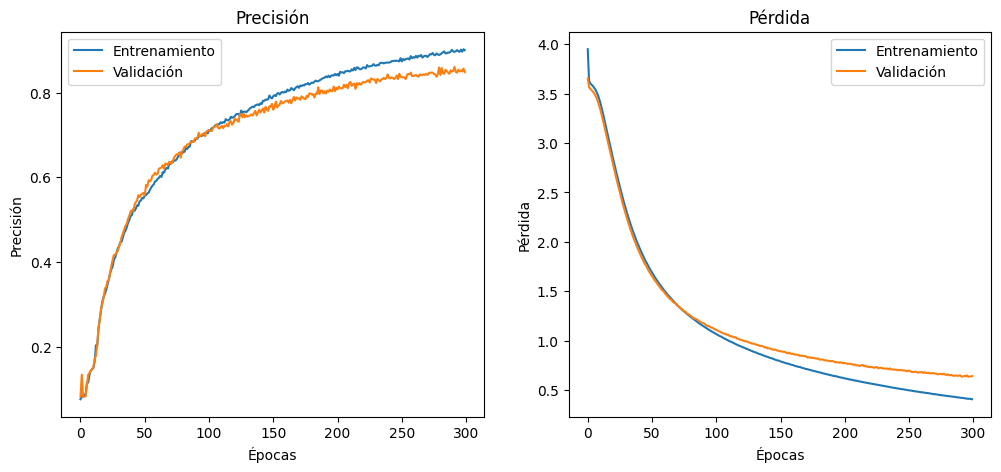

In [16]:
plt.figure(figsize=(12, 5))

# Precisión
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Validación')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Precisión')
plt.legend()

# Pérdida
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Entrenamiento')
plt.plot(history.history['val_loss'], label='Validación')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Pérdida')
plt.legend()

plt.show()